<a href="https://colab.research.google.com/github/ChahatUpadhyay/AI_Smartinez_Work/blob/main/notebooks/Jellyfish_2_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import cv2

In [ ]:
data_dir = "/content/drive/MyDrive/JellyFIsh/"
img_height, img_width = 224, 224
batch_size = 32
num_classes = 6

In [ ]:
Moon_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/Moon_jellyfish"
barrel_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/barrel_jellyfish"
blue_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/blue_jellyfish"
compass_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/compass_jellyfish"
lions_mane_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/lions_mane_jellyfish"
mauve_stinger_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/mauve_stinger_jellyfish"

# Function to load and preprocess images
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            img = cv2.resize(img, (224, 224))
            images.append(img)
    return images

Moon_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/Moon_jellyfish"
barrel_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/barrel_jellyfish"
blue_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/blue_jellyfish"
compass_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/compass_jellyfish"
lions_mane_jellyfish_folder = "/content/drive/MyDrive/JellyFIsh/lions_mane_jellyfish"
mauve_stinger_jellyfish = "/content/drive/MyDrive/JellyFIsh/mauve_stinger_jellyfish"

# Loading images and labels for each emotion
Moon_images = load_images_from_folder(Moon_jellyfish_folder)
barrel_images = load_images_from_folder(barrel_jellyfish_folder)
blue_images = load_images_from_folder(blue_jellyfish_folder)
compass_images = load_images_from_folder(compass_jellyfish_folder)
lions_mane_images = load_images_from_folder(lions_mane_jellyfish_folder)
mauve_stinger_images = load_images_from_folder(mauve_stinger_jellyfish_folder)


# Creating labels for each emotion category
Moon_labels = [0] * len(Moon_images)
barrel_labels = [1] * len(barrel_images)
blue_labels = [2] * len(blue_images)
compass_labels = [3] * len(compass_images)
lions_mane_labels = [4] * len(lions_mane_images)
mauve_stinger_labels = [5] * len(mauve_stinger_images)

all_labels = Moon_labels+barrel_labels+blue_labels+compass_labels+lions_mane_labels+mauve_stinger_labels


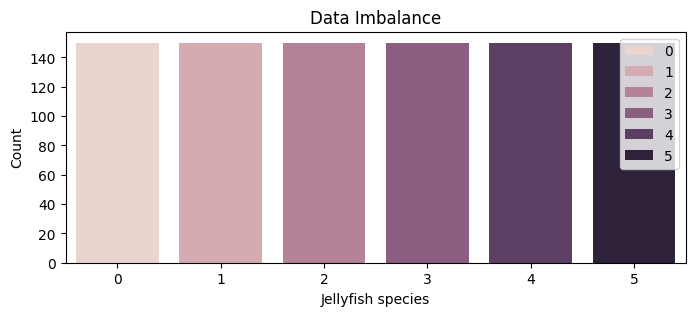

In [ ]:
# checking for Data Imbalance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 3))
sns.countplot(x=all_labels, hue=all_labels)
plt.title('Data Imbalance')
plt.xlabel('Jellyfish species')
plt.ylabel('Count')
plt.show()

In [ ]:
#Concatenate images and labels
import numpy as np
X = np.array(Moon_images + barrel_images + blue_images + compass_images + lions_mane_images + mauve_stinger_images)
y = np.array(Moon_labels + barrel_labels + blue_labels + compass_labels + lions_mane_labels + mauve_stinger_labels)

#Normalize pixel values to range [0, 1]
X = X.astype('float32') / 255.0

Data Augmentation

In [ ]:
# here we will double each jellyfish type images
# earlier 150 in each
# after this 600 images for each class
# 3600 total Images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters and paths
data_dir = "/content/drive/MyDrive/JellyFIsh"
classes = [
    "Moon_jellyfish",
    "barrel_jellyfish",
    "blue_jellyfish",
    "compass_jellyfish",
    "lions_mane_jellyfish",
    "mauve_stinger_jellyfish"
]
img_height, img_width = 224, 224

# Defining the ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Lists to hold the augmented images and corresponding labels
augmented_dataset = []
labels = []

# Loop through each class folder and process images
for label, class_name in enumerate(classes):
    class_folder = os.path.join(data_dir, class_name)
    image_files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    print(f"Processing class: {class_name} with {len(image_files)} images")

    for img_file in image_files:
        img_path = os.path.join(class_folder, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        # Resizing image to target dimensions and convert from BGR to RGB
        img = cv2.resize(img, (img_width, img_height))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        augmented_dataset.append(img)
        labels.append(label)

        x = np.expand_dims(img, axis=0)
        aug_iter = datagen.flow(x, batch_size=1)
        # generating 3 more images
        for i in range(3):
            aug_img = next(aug_iter)[0]
            aug_img = np.clip(aug_img, 0, 255).astype(np.uint8)
            augmented_dataset.append(aug_img)
            labels.append(label)

# Convert lists to numpy arrays
augmented_dataset = np.array(augmented_dataset)
labels = np.array(labels)

print("Augmented dataset shape:", augmented_dataset.shape)
print("Labels shape:", labels.shape)


Processing class: Moon_jellyfish with 150 images
Processing class: barrel_jellyfish with 150 images
Processing class: blue_jellyfish with 150 images
Processing class: compass_jellyfish with 150 images
Processing class: lions_mane_jellyfish with 150 images
Processing class: mauve_stinger_jellyfish with 150 images
Augmented dataset shape: (3600, 224, 224, 3)
Labels shape: (3600,)


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

num_classes = len(classes)
augmented_dataset = augmented_dataset.astype('float32') / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    augmented_dataset, labels, test_size=0.2, random_state=42, stratify=labels
)
y_train = to_categorical(y_train, num_classes=num_classes)
y_val = to_categorical(y_val, num_classes=num_classes)


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load VGG16 with pre-trained ImageNet weights (excluding top layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers (initially)
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

# Training the model
epochs = 10
batch_size = 32

history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, lr_scheduler]
)


Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 39s 289ms/step - accuracy: 0.3918 - loss: 1.5891 - val_accuracy: 0.8333 - val_loss: 0.6467 - learning_rate: 1.0000e-04
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.8098 - loss: 0.6254 - val_accuracy: 0.8889 - val_loss: 0.4190 - learning_rate: 1.0000e-04
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - accuracy: 0.8942 - loss: 0.3699 - val_accuracy: 0.9319 - val_loss: 0.2908 - learning_rate: 1.0000e-04
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.9436 - loss: 0.2556 - val_accuracy: 0.9181 - val_loss: 0.2488 - learning_rate: 1.0000e-04
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 213ms/step - accuracy: 0.9599 - loss: 0.1871 - val_accuracy: 0.9556 - val_loss: 0.1875 - learning_rate: 1.0000e-04
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - accuracy: 0.9736 - loss: 0.1486 - val_accuracy: 0.9542 - val_loss: 0.1649 - learning_rate: 1.0000e-04
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - acc

In [ ]:
# Evaluate on validation set
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Final Validation Accuracy: {val_acc:.4f}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.9717 - loss: 0.1065
Final Validation Accuracy: 0.9708


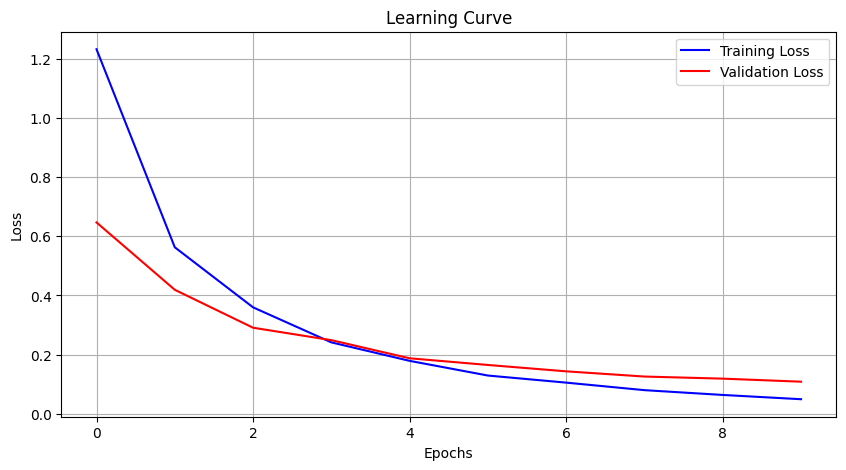

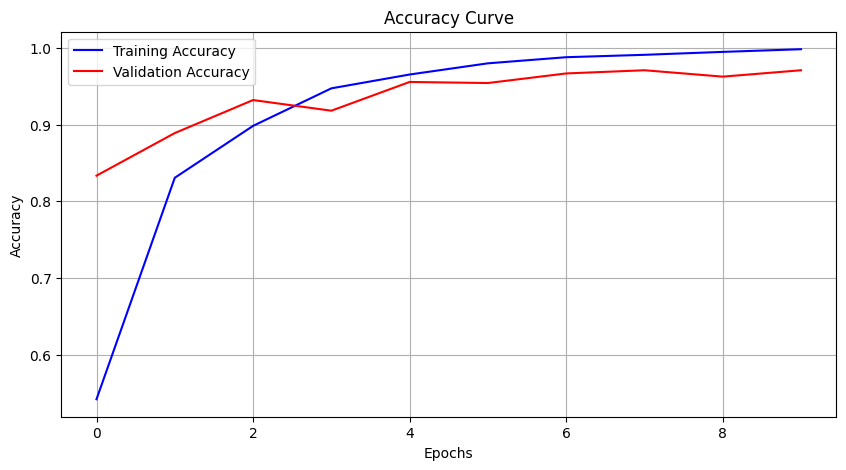

In [ ]:
import matplotlib.pyplot as plt

# Function to plot loss curves
def plot_learning_curves(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid()
    plt.show()

# Function to plot accuracy curves
def plot_accuracy_curves(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.grid()
    plt.show()

# Plot the curves
plot_learning_curves(history)
plot_accuracy_curves(history)


In [ ]:
import pickle

# Save the trained model
model.save("/content/drive/MyDrive/VGG16_Jellyfish_Classifier_.h5")

with open('/content/drive/MyDrive/VGG16_Jellyfish_History.pkl', 'wb') as f:
    pickle.dump(history.history, f)



**Fine Tunning the VGG16 Model**

In [ ]:
# Unfreeze last few layers for fine-tuning
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/VGG16_Jellyfish_Classifier_.h5")
model.summary()

# Unfreeze last 5 layers for fine-tuning
for layer in model.layers[-5:]:
    layer.trainable = True

# Recompile model with a lower learning rate
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 21,139,016 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

# Fine-tune the model
epochs_finetune = 20
batch_size = 32

history_finetune = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs_finetune,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 219ms/step - accuracy: 0.9976 - loss: 0.0433 - val_accuracy: 0.9736 - val_loss: 0.1009 - learning_rate: 1.0000e-05
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 220ms/step - accuracy: 0.9965 - loss: 0.0431 - val_accuracy: 0.9722 - val_loss: 0.1007 - learning_rate: 1.0000e-05
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - accuracy: 0.9974 - loss: 0.0344 - val_accuracy: 0.9764 - val_loss: 0.0974 - learning_rate: 1.0000e-05
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.9973 - loss: 0.0342 - val_accuracy: 0.9722 - val_loss: 0.0960 - learning_rate: 1.0000e-05
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 215ms/step - accuracy: 0.9998 - loss: 0.0350 - val_accuracy: 0.9736 - val_loss: 0.0974 - learning_rate: 1.0000e-05
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 222ms/step - accuracy: 0.9988 - loss: 0.0313 - val_accuracy: 0.9750 - val_loss: 0.0944 - learning_rate: 1.0000e-05
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 237ms/step - acc

In [ ]:
# Evaluate final validation accuracy
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Final Validation Accuracy: {val_acc:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.9792 - loss: 0.0767
Final Validation Accuracy: 0.9750


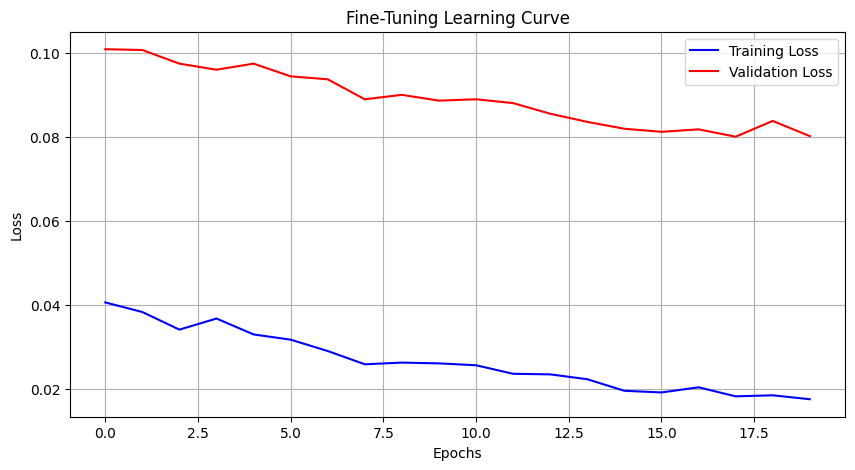

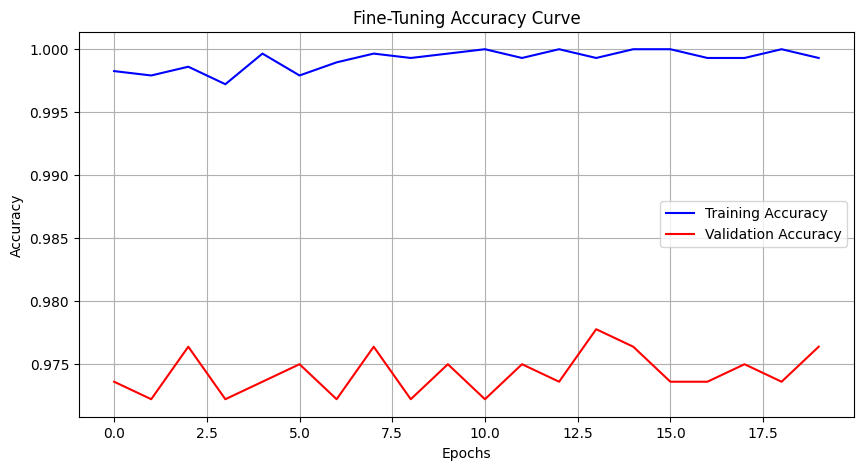

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Fine-Tuning Learning Curve')
    plt.legend()
    plt.grid()
    plt.show()

def plot_accuracy_curves(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Fine-Tuning Accuracy Curve')
    plt.legend()
    plt.grid()
    plt.show()

# Plot the fine-tuned model's curves
plot_learning_curves(history_finetune)
plot_accuracy_curves(history_finetune)


In [ ]:
import pickle
# Save the fine-tuned model
model.save("/content/drive/MyDrive/VGG16_Jellyfish_Classifier_Finetuned.h5")

with open('/content/drive/MyDrive/VGG16_Jellyfish_Finetune_History.pkl', 'wb') as f:
    pickle.dump(history_finetune.history, f)


Select Model:
1. Normal Model
2. Fine-Tuned Model
Enter 1 or 2: 2


Using Fine-Tuned Model for Prediction


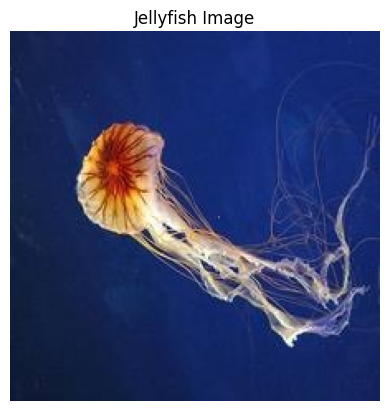

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: Compass Jellyfish
Class Probabilities: [[5.2936841e-05 5.4871311e-06 9.1164817e-05 9.9933714e-01 3.3355740e-04
  1.7965231e-04]]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load models
normal_model_path = "/content/drive/MyDrive/VGG16_Jellyfish_Classifier_.h5"
finetuned_model_path = "/content/drive/MyDrive/VGG16_Jellyfish_Classifier_Finetuned.h5"

print("Select Model:")
print("1. Normal Model")
print("2. Fine-Tuned Model")

choice = input("Enter 1 or 2: ")

if choice == "1":
    model = load_model(normal_model_path)
    print("Using Normal Model for Prediction")
elif choice == "2":
    model = load_model(finetuned_model_path)
    print("Using Fine-Tuned Model for Prediction")
else:
    print("Invalid choice! Defaulting to Normal Model")
    model = load_model(normal_model_path)

# Define class names
class_names = {
    0: "Moon Jellyfish",
    1: "Barrel Jellyfish",
    2: "Blue Jellyfish",
    3: "Compass Jellyfish",
    4: "Lions Mane Jellyfish",
    5: "Mauve Stinger Jellyfish"
}

def classify_jellyfish(image_path, model, input_shape):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None, None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (input_shape[0], input_shape[1]))

    # Normalize pixel values to [0, 1]
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict using the selected model
    probabilities = model.predict(img)
    class_idx = np.argmax(probabilities, axis=1)[0]

    predicted_class = class_names.get(class_idx, "Unknown")

    return predicted_class, probabilities

# Example usage:
image_path = "/content/drive/MyDrive/JellyFIsh/compass_jellyfish/03.jpg"

# Display the image
img = cv2.imread(image_path)
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Jellyfish Image")
    plt.show()

predicted_class, probs = classify_jellyfish(image_path, model, (224, 224, 3))

print("Predicted Class:", predicted_class)
print("Class Probabilities:", probs)
